# Genetic Algorithm

## 1. Lab Title

**Optimization Using Genetic Algorithm (GA)**


# PART A: INTRODUCTION

## 2. Theoretical Background

### 2.1 What is a Genetic Algorithm?

A Genetic Algorithm (GA) is a population-based metaheuristic inspired by the process of natural selection. It is used to solve optimization and search problems.

### 2.2 Basic Terminology

- **Chromosome**: A candidate solution.
- **Gene**: A part of a chromosome.
- **Population**: Set of candidate solutions.
- **Fitness Function**: Function used to evaluate solution quality.
- **Selection**: Choosing parents for reproduction.
- **Crossover**: Combining two parents to produce offspring.
- **Mutation**: Random modification to maintain diversity.
- **Generation**: One iteration of evolution.

### 2.3 General Flow of Genetic Algorithm

1. Initialize population randomly.
2. Evaluate fitness of each individual.
3. Select parents.
4. Perform crossover.
5. Perform mutation.
6. Replace old population.
7. Repeat until stopping condition is met.


# PART B: HANDS-ON IMPLEMENTATION

## 3. Example Problem: Maximize a Mathematical Function

### Problem Statement

Maximize the function:
f(x) = x²


Where x is in the range [0, 31]

### 3.1 Encoding Scheme

Since 0–31 can be represented using 5 bits:

- Chromosome length = 5 bits
- Example:
  - 10101 → 21
  - 00111 → 7

### 3.2 Fitness Function

Fitness = f(x) = x²

### 3.3 GA Parameters

- Population size = 6
- Crossover probability = 0.8
- Mutation probability = 0.1
- Generations = 20


## 4. Step-by-Step Algorithm

### Step 1: Initialize Population

Example initial population:

| Chromosome | Decimal | Fitness |
| ---------- | ------- | ------- |
| 10101      | 21      | 441     |
| 00111      | 7       | 49      |
| 11100      | 28      | 784     |
| 01010      | 10      | 100     |
| 11001      | 25      | 625     |
| 00011      | 3       | 9       |

### Step 2: Selection (Roulette Wheel)

Probability = Fitness / Total Fitness

### Step 3: Crossover (Single-Point)

Parent1: 101|01  
Parent2: 111|00  
Offspring1: 10100  
Offspring2: 11101

### Step 4: Mutation

Random bit flip:  
10100 → 10000

### Step 5: Repeat for N generations

## 5. Sample Python Implementation

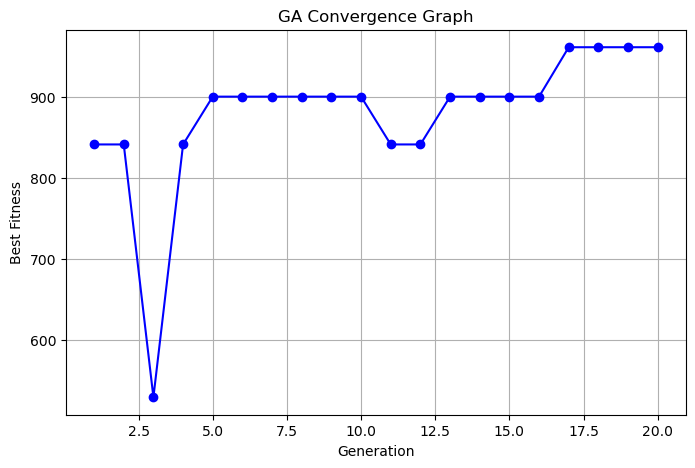

('11111',
 31,
 961,
 [841,
  841,
  529,
  841,
  900,
  900,
  900,
  900,
  900,
  900,
  841,
  841,
  900,
  900,
  900,
  900,
  961,
  961,
  961,
  961])

In [ ]:
import random
import matplotlib.pyplot as plt

# GA Parameters
POP_SIZE = 6
CHROMOSOME_LENGTH = 5
GENERATIONS = 20
MUTATION_RATE = 0.1

# Fitness function
def fitness(chromosome):
    x = int(chromosome, 2)
    return x**2

# Generate random chromosome
def random_chromosome():
    return ''.join(random.choice('01') for _ in range(CHROMOSOME_LENGTH))

# Roulette Wheel Selection
def selection(population):
    total_fitness = sum(fitness(c) for c in population)
    probs = [fitness(c)/total_fitness for c in population]
    return random.choices(population, probs)[0]

# Single-point crossover
def crossover(p1, p2):
    point = random.randint(1, CHROMOSOME_LENGTH-1)
    return p1[:point] + p2[point:], p2[:point] + p1[point:]

# Mutation
def mutation(chromosome):
    new_chromosome = ''
    for gene in chromosome:
        if random.random() < MUTATION_RATE:
            new_chromosome += '1' if gene == '0' else '0'
        else:
            new_chromosome += gene
    return new_chromosome

# Initialize population
population = [random_chromosome() for _ in range(POP_SIZE)]
best_fitness_per_gen = []

# GA main loop
for _ in range(GENERATIONS):
    new_population = []
    for _ in range(POP_SIZE//2):
        p1 = selection(population)
        p2 = selection(population)
        c1, c2 = crossover(p1, p2)
        new_population.extend([mutation(c1), mutation(c2)])
    population = new_population
    # Record best fitness in current generation
    best_fitness_per_gen.append(fitness(max(population, key=fitness)))

# Best solution
best = max(population, key=fitness)
best_decimal = int(best,2)
best_value = fitness(best)

# Plot convergence graph
plt.figure(figsize=(8,5))
plt.plot(range(1, GENERATIONS+1), best_fitness_per_gen, marker='o', color='blue')
plt.title('GA Convergence Graph')
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.grid(True)
plt.show()

best, best_decimal, best_value, best_fitness_per_gen

## 6. Lab Task

### Objective
Read and understand the research paper:  
**"Optimal One Day International Cricket Team Selection by Genetic Algorithm"**

### Summary
The paper proposes a **Genetic Algorithm (GA)**–based approach for selecting an **optimal cricket squad**. Key points include:

- **Goal:** Select a squad of **15 players** from a pool of **30 players**.  
- **Factors Considered:** Multiple **performance metrics** such as batting average, bowling economy, strike rates, etc.  
- **Constraints:** Role-based requirements (e.g., minimum number of batsmen, bowlers, all-rounders, wicket-keepers).  
- **Methodology:**  
  1. **Initialization:** Generate a population of possible squads randomly.  
  2. **Fitness Function:** Evaluate each squad based on performance metrics and constraints.  
  3. **Selection:** Choose top-performing squads for reproduction.  
  4. **Crossover:** Combine parts of two squads to produce new candidates.  
  5. **Mutation:** Randomly swap or replace players to maintain diversity.  
  6. **Iteration:** Repeat until optimal squad is found or maximum generations reached.  
- **Outcome:** The GA efficiently selects a balanced and high-performing squad considering both individual performance and team composition.



Optimal Squad Selected:

Upul Tharanga - Batsman
Lasith Malinga - FastBowler
Tillakaratne Dilshan - AllRounder
Thisara Perera - AllRounder
Mahela Jayawardene - Batsman
Rangana Herath - Spinner
Kusal Perera - Batsman
Jeevan Mendis - AllRounder
Sachithra Senanayake - Spinner
Ajantha Mendis - Spinner
Seekkuge Prasanna - AllRounder
Angelo Mathews - AllRounder
Mahela Jayawardene - Batsman
Kithuruwan Vithanage - Batsman
Nuwan Kulasekara - FastBowler


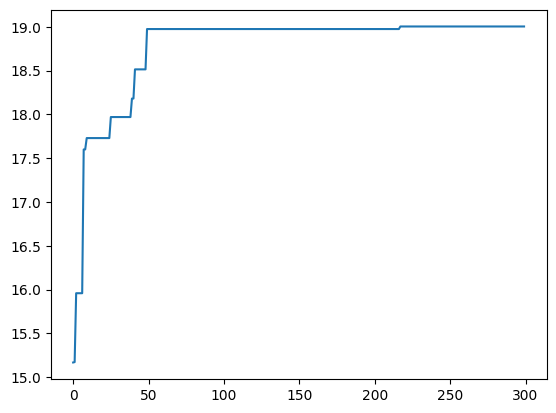

In [6]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# 1. LOAD DATASET
# ======================================

def load_players_from_csv(filename):
    """
    Load CSV file of players.
    Return a list of player dictionaries.
    """
    df = pd.read_csv(filename)
    return df.to_dict(orient = 'records')
    # TODO: implement CSV loading

# ======================================
# 2. RANKING FUNCTIONS
# ======================================

def rank_players(players, key, reverse=False):
    """
    Rank players based on a specific key (bat_avg, bowl_avg, etc.)
    """
    sorted_players = sorted(players, key=lambda i: i[key], reverse=not reverse)

    ranks = {}
    for rank, player in enumerate(sorted_players, start=1):
        ranks[player["player_id"]] = rank
    return ranks
    # TODO: implement ranking

def compute_all_ranks(players):
    """
    Compute ranks for all performance metrics.
    """
    ranks= {}
    vals = ['bat_avg','bowl_avg','strike_rate','wickets_per_match','win_loss_ratio','experience']

    for i in vals:
        if i == 'bowl_avg' :
            ranks['bowl_avg'] = rank_players(players, i, True)
        else:
            ranks[i] = rank_players(players, i, False)

    return ranks
    # TODO: implement multiple rankings

# ======================================
# 3. FITNESS FUNCTIONS
# ======================================

def player_fitness(player_id, ranks):
    """
    Compute fitness score for a single player.
    """
    score = 0
    for metric in ranks:
        score += (1/ranks[metric][player_id])
    return score
        # TODO: implement fitness calculation

def team_fitness(team, ranks):
    """
    Compute fitness score for the entire team.
    """
    return sum(player_fitness(pid, ranks) for pid in team)
    # TODO: implement team fitness

# ======================================
# 4. TEAM CONSTRAINTS
# ======================================

def is_valid_team(team, players):
    """
    Check if team satisfies constraints:
    - Number of Batsmen, Spinners, FastBowler, AllRounder, WicketKeeper
    """
    player_types= {
        'Batsman':0,
        'AllRounder': 0,
        'FastBowler': 0,
        'Spinner':0,
        'WicketKeeper': 0
    }
    player_lookup = {p["player_id"]: p for p in players}

    for pid in team:
        role = player_lookup[pid]['role']
        if role in player_types:
            player_types[role] += 1

     # TODO: implement validation
    if 6 <= player_types['Batsman'] <= 4:
        return False
    elif 1 <= player_types['Spinner'] <= 3:
        return False
    elif  3 <= player_types['FastBowler'] <= 5:
        return False
    elif  1 <= player_types['AllRounder'] <= 4:
        return False
    elif  1 <= player_types['WicketKeeper'] <= 3:
        return False
    else: return True



def create_random_team(players):
    """
    Generate a valid random team of 15 players.
    """
    while True:
        team = random.sample([p["player_id"] for p in players], 15)
        if is_valid_team(team, players):
            return team
  # TODO: implement random team generation

# ======================================
# 5. GENETIC OPERATORS
# ======================================

def crossover(parent1, parent2, players):
    """
    Combine two parent teams to produce a child team.
    """
    cutting = random.randint(5, 10)
    p1 = parent1[:cutting]
    p2 = parent2[cutting:]
    child = p1 + p2

    child = list(dict.fromkeys(child))

    all_ids = [p["player_id"] for p in players]
    while len(child) < 15:
        x = random.choice(all_ids)
        if x not in child:
            child.append(x)
    if not is_valid_team(child, players):
        return create_random_team(players)

    return child

    # TODO: implement crossover logic

def mutation(team, players):
    """
    Randomly mutate a team by changing one player.
    """
    mutation_rate = 0.05
    if random.random() < mutation_rate:
        player_to_change = random.choice(team)
        new_player = random.choice([p["player_id"] for p in players if p["player_id"] != player_to_change])
        team[team.index(player_to_change)] = new_player
    return team

        # TODO: implement mutation

# ======================================
# 6. TOURNAMENT SELECTION
# ======================================

def tournament_selection(population, ranks, k=3):
    """
    Select teams from the population using tournament selection.;"""
    selected = random.sample(population, k)
    selected.sort(key=lambda team: team_fitness(team, ranks), reverse=True)
    return selected[0]

    # TODO: implement tournament selection

# ======================================
# 7. GENETIC ALGORITHM
# ======================================

def genetic_algorithm(players, ranks, pop_size=20, generations=300):
    """
    Main Genetic Algorithm:
    - Initialize population
    - Evaluate fitness
    - Selection
    - Crossover
    - Mutation
    - Keep track of best fitness
    """
    population = [create_random_team(players) for _ in range(pop_size)]
    fitness_history = []

    best_team = None
    best_fitness = 0

    for _ in range(generations):

        new_population = []

        for _ in range(pop_size):
            parent1 = tournament_selection(population, ranks)
            parent2 = tournament_selection(population, ranks)

            child = crossover(parent1, parent2, players)
            child = mutation(child, players)

            new_population.append(child)

        population = new_population

        # Track best
        for team in population:
            fitness = team_fitness(team, ranks)
            if fitness > best_fitness:
                best_fitness = fitness
                best_team = team

        fitness_history.append(best_fitness)

    return best_team, fitness_history
# TODO: implement GA loop

    return [], []  # Return best team and fitness history

# ======================================
# 8. PLOT FITNESS
# ======================================

def plot_fitness_curve(fitness_history):
  plt.figure
  plt.plot(fitness_history)
  plt.show()


# ======================================
# 9. MAIN
# ======================================

def main():
    # Load players
    players = load_players_from_csv("sri_lanka_players.csv")

    # Compute ranks
    ranks = compute_all_ranks(players)

    # Run Genetic Algorithm
    best_team, history = genetic_algorithm(players, ranks, pop_size=20, generations=300)

    # Display optimal team
    print("\nOptimal Squad Selected:\n")
    for pid in best_team:
        player = next(p for p in players if p["player_id"] == pid)
        print(f"{player['name']} - {player['role']}")

    # Plot fitness curve
    plot_fitness_curve(history)

if __name__ == "__main__":
    main()


# Lab Task for Practice: Knapsack Problem Using Genetic Algorithm

## Objective
The **Knapsack Problem** is a classic optimization problem where the goal is to **maximize the total value of selected items** while ensuring that the total weight remains within a given capacity. In this lab, we will implement a **Genetic Algorithm (GA)** to find an optimal solution for this problem.


## Problem Statement
You are given a set of **n items**, each defined by:

- **Weight (w[i])**  
- **Value (v[i])**

The objective is to select a subset of items that **maximizes the total value** while ensuring the **total weight does not exceed 10 kg**.

| Item | N1 | N2 | N3 | N4 | N5 | N6 |
|------|----|----|----|----|----|----|
| Value | 14 | 23 | 8  | 9  | 17 | 15 |
| Weight (Kg) | 1  | 3  | 7  | 4  | 5  | 6 |

## Genetic Algorithm Implementation Steps

### 1. Initialization
- Generate an initial population of `pop_size` individuals.  
- Each individual is represented as a **binary string of length n**, where each bit indicates whether an item is included (`1`) or not (`0`).

### 2. Fitness Function
- Calculate the **total value** of selected items.  
- Apply a **penalty** to solutions exceeding the weight capacity (10 kg).  
- The fitness function should return a value that reflects the **quality of the solution**.


### 3. Selection
- Select 2 individuals based on their **fitness values**.  
- Use **tournament selection**.

**Example:**  

| Individual | Chromosome          | Fitness |
|------------|-------------------|---------|
| 1          | [1, 0, 1, 1, 0, 0] | 23      |
| 2          | [0, 1, 1, 0, 1, 1] | 30      |
| 3          | [1, 1, 0, 1, 1, 0] | 27      |

**Tournament Selection (k=3):**  
- Randomly pick 3 individuals.  
- The one with the **highest fitness** is selected.


### 4. Crossover
- Generate two **offspring** by applying a **crossover technique**.  
- Use **one-point crossover** to combine parent solutions.

### 5. Mutation
- Each bit in the chromosome has a small probability of flipping (`0 → 1` or `1 → 0`).

**Steps:**  
1. Choose a **mutation probability** (`mut_prob`).  
2. Flip bits randomly based on `mut_prob`.

**Example (`mut_prob = 0.1`):**  
Before Mutation: 101011

After Mutation: 100011 (Bit at index 1 flipped)


### 6. Replacement
- Replace the **least-fit individuals** in the population with the newly generated **offspring**.


### 7. Termination
- Repeat **steps 3–6** for `max_gen` generations, or until a **satisfactory solution** is found.


By implementing this **Genetic Algorithm**, you will find an optimal or near-optimal subset of items that **maximizes the total value** while **staying within the weight limit**.


In [ ]:
# Solution